<a href="https://colab.research.google.com/github/va4756/deeplearn_practice/blob/main/nlp_transformer_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/rickiepark/nlp-with-transformers.git
%cd nlp-with-transformers
from install import *
install_requirements(chapter=1)

Cloning into 'nlp-with-transformers'...
remote: Enumerating objects: 726, done.
remote: Counting objects: 100% (228/228), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 726 (delta 220), reused 209 (delta 209), pack-reused 498 (from 1)
Receiving objects: 100% (726/726), 64.94 MiB | 23.22 MiB/s, done.
Resolving deltas: 100% (390/390), done.
/content/nlp-with-transformers
⏳ Installing base requirements ...
✅ Base requirements installed!
Using transformers v4.57.6
Using datasets v4.0.0
Using accelerate v1.14.0
Using sentencepiece v0.2.1
Using sacremoses v0.1.1
No GPU was detected! This notebook can be *very* slow without a GPU 🐢
Go to Runtime > Change runtime type and select a GPU hardware accelerator.


# chap1.트래스포머 소개

In [ ]:
text = """Dear Amazon, last week I ordered an Optimus Prime action figure \
from your online store in Germany. Unfortunately, when I opened the package, \
I discovered to my horror that I had been sent an action figure of Megatron \
instead! As a lifelong enemy of the Decepticons, I hope you can understand my \
dilemma. To resolve the issue, I demand an exchange of Megatron for the \
Optimus Prime figure I ordered. Enclosed are copies of my records concerning \
this purchase. I expect to hear from you soon. Sincerely, Bumblebee."""

In [ ]:
from transformers import pipeline
classifier = pipeline("text-classification")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
import pandas as pd
outputs = classifier(text)
pd.DataFrame(outputs)

,label,score
0,NEGATIVE,0.901546


## 1-1.개체명 인식

In [ ]:
ner_tagger = pipeline("ner", aggregation_strategy="simple")
outputs = ner_tagger(text)
pd.DataFrame(outputs)

config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

,entity_group,score,word,start,end
0,ORG,0.879010,Amazon,5,11
1,MISC,0.990859,Optimus Prime,36,49
2,LOC,0.999755,Germany,90,97
3,MISC,0.556570,Mega,208,212
4,PER,0.590256,##tron,212,216
5,ORG,0.669692,Decept,253,259
6,MISC,0.498349,##icons,259,264
7,MISC,0.775362,Megatron,350,358
8,MISC,0.987854,Optimus Prime,367,380
9,PER,0.812096,Bumblebee,502,511


In [ ]:
reader = pipeline("question-answering")
question = "What does the customer want?"
outputs = reader(question=question, context=text)
pd.DataFrame([outputs])

,score,start,end,answer
0,0.631292,335,358,an exchange of Megatron


## 1-2.요약

In [ ]:
summarizer = pipeline("summarization")
outputs = summarizer(text, max_length=60, clean_up_tokenization_spaces=True)
print(outputs[0]["summary_text"])

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

 Bumblebee ordered an Optimus Prime action figure from your online store in
Germany. Unfortunately, when I opened the package, I discovered to my horror
that I had been sent an action figure of Megatron instead. As a lifelong enemy
of the Decepticons, I hope you can understand


## 1-3.번역

In [ ]:
translator = pipeline("translation_en_to_de",
                      model="Helsinki-NLP/opus-mt-en-de")
outputs = translator(text, clean_up_tokenization_spaces=True, min_length=100)
print(outputs[0]['translation_text'])

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/298M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/298M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/797k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

Sehr geehrter Amazon, letzte Woche habe ich eine Optimus Prime Action Figur aus
Ihrem Online-Shop in Deutschland bestellt. Leider, als ich das Paket öffnete,
entdeckte ich zu meinem Entsetzen, dass ich stattdessen eine Action Figur von
Megatron geschickt worden war! Als lebenslanger Feind der Decepticons, Ich
hoffe, Sie können mein Dilemma verstehen. Um das Problem zu lösen, Ich fordere
einen Austausch von Megatron für die Optimus Prime Figur habe ich bestellt.
Eingeschlossen sind Kopien meiner Aufzeichnungen über diesen Kauf. Ich erwarte,
von Ihnen bald zu hören. Aufrichtig, Bumblebee.


In [ ]:
# 영어 → 한국어
# from transformers import pipeline

# translator = pipeline(
#     "translation",
#     model="Helsinki-NLP/opus-mt-en-ko"  # 이 모델이 존재하지 않음
# )

# text = "Machine learning is changing the world."

# outputs = translator(text)

# print(outputs[0]["translation_text"])

OSError: Helsinki-NLP/opus-mt-en-ko is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`

In [ ]:
# 한국어 → 영어
# from transformers import pipeline

# translator = pipeline(
#     "translation",
#     model="Helsinki-NLP/opus-mt-ko-en"   # 이 모델이 존재하지 않음
# )

# text = "안녕하세요. 만나서 반갑습니다."

# outputs = translator(text)

# print(outputs[0]["translation_text"])

### 작동하지만 사이즈가 매우 큼

In [ ]:
# from transformers import pipeline

# translator = pipeline(
#     "translation",
#     model="facebook/nllb-200-distilled-600M"
# )

# text = "Machine learning is changing the world."

# result = translator(
#     text,
#     src_lang="eng_Latn",
#     tgt_lang="kor_Hang"
# )

# print(result[0]["translation_text"])

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

머신러닝은 세상을 변화시키고 있습니다.


In [18]:
# # Google MADLAD
# from transformers import pipeline

# translator = pipeline(
#     "translation",
#     model="google/madlad400-3b-mt"
# )

config.json:   0%|          | 0.00/749 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/11.8G [00:00<?, ?B/s]

KeyboardInterrupt: 

## 1-4.텍스트 생성

In [ ]:
from transformers import set_seed
set_seed(42)

In [ ]:
generator = pipeline("text-generation")
response = "Dear Bumblebee, I am sorry to hear that your order was mixed up."
prompt = text + "\n\nCustomer service response:\n" + response
outputs = generator(prompt, max_length=20)
print(outputs[0]["generated_text"])

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Dear Amazon, last week I ordered an Optimus Prime action figure from your online
store in Germany. Unfortunately, when I opened the package, I discovered to my
horror that I had been sent an action figure of Megatron instead! As a lifelong
enemy of the Decepticons, I hope you can understand my dilemma. To resolve the
issue, I demand an exchange of Megatron for the Optimus Prime figure I ordered.
Enclosed are copies of my records concerning this purchase. I expect to hear
from you soon. Sincerely, Bumblebee.

Customer service response:
Dear Bumblebee, I am sorry to hear that your order was mixed up., there was a
problem loading in the loading screens: when the figure was opened and the
action figure was in the loading screens, it would not load properly and its
action figure would not play. In other words, I was unable to activate his
action figure. I have had this problem a few times before, and with the Optimus
Prime action figure, I had to restart the game. I have also had this probl

# chap2.텍스트 분류

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
!git clone https://github.com/rickiepark/nlp-with-transformers.git
%cd nlp-with-transformers
from install import *
install_requirements(chapter=2)

Cloning into 'nlp-with-transformers'...
remote: Enumerating objects: 726, done.
remote: Counting objects: 100% (228/228), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 726 (delta 220), reused 209 (delta 209), pack-reused 498 (from 1)
Receiving objects: 100% (726/726), 64.94 MiB | 16.91 MiB/s, done.
Resolving deltas: 100% (390/390), done.
/content/nlp-with-transformers/nlp-with-transformers
⏳ Installing base requirements ...
✅ Base requirements installed!
Using transformers v4.57.6
Using datasets v4.0.0
Using accelerate v1.14.0
Using sentencepiece v0.2.1
Using umap v0.5.12
No GPU was detected! This notebook can be *very* slow without a GPU 🐢
Go to Runtime > Change runtime type and select a GPU hardware accelerator.


## 2-1.허깅 페이스 데이터셋 처음 사용하기

In [25]:
from huggingface_hub import list_datasets

datasets = list(list_datasets(limit=20))

for ds in datasets:
    print(ds.id)

FlyRank/internship-warehouse
markov-ai/gaming-500-hours
LiquidAI/antidoom-mix-v1.0
Glint-Research/Fable-5-traces
openbmb/UltraX-Preview
ByteDance-Seed/EdgeBench
netflix/Vera-Layered-Video-Dataset
AlicanKiraz0/Turkce-Atlas-Instruct
sensenova/SenseNova-Vision-Corpus-50M
Crownelius/Complete-FABLE.5-traces-2M
ProCreations/grug-think
wikimedia/wikipedia
armand0e/claude-fable-5-claude-code
CMRobot/MotionDecode
bigfacing/GOKU-2M
SupraLabs/reasoning-corpus-4K-5M-v1
WithinUsAI/claude_mythos_distilled_25k
LiquidAI/ifstruct-v1.0
scholarweave/arxiv-latex
kyutai/rocket-science


In [26]:
# from huggingface_hub import list_datasets

# all_datasets = [ds.id for ds in list_datasets()]
# print(f"현재 허브에는 {len(all_datasets)}개의 데이터셋이 있습니다.")
# print(f"처음 10개 데이터셋: {all_datasets[:10]}")

In [27]:
from datasets import load_dataset

emotions = load_dataset("emotion")

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [29]:
# SetFit/emotion 데이터셋의 경우 수동으로 ClassLabel 객체를 만들어 label에 할당합니다.
from datasets import ClassLabel

emotions['train'].features['label'] = ClassLabel(
    num_classes=6,
    names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])

In [30]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [31]:
train_ds = emotions["train"]
train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [32]:
len(train_ds)

16000

In [33]:
train_ds[0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [34]:
train_ds.column_names

['text', 'label']

In [35]:
print(train_ds.features)

{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love',
'anger', 'fear', 'surprise'])}


In [36]:
print(train_ds[:5])

{'text': ['i didnt feel humiliated', 'i can go from feeling so hopeless to so
damned hopeful just from being around someone who cares and is awake', 'im
grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic
about the fireplace i will know that it is still on the property', 'i am feeling
grouchy'], 'label': [0, 0, 3, 2, 3]}


In [37]:
print(train_ds["text"][:5])

['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned
hopeful just from being around someone who cares and is awake', 'im grabbing a
minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the
fireplace i will know that it is still on the property', 'i am feeling grouchy']


## 2-2.사이드바: 허브에 필요한 데이터셋이 없다면 어떻게 하나요?

In [38]:
dataset_url = "https://huggingface.co/datasets/transformersbook/emotion-train-split/raw/main/train.txt"
!wget {dataset_url}

--2026-07-15 07:17:59--  https://huggingface.co/datasets/transformersbook/emotion-train-split/raw/main/train.txt
Resolving huggingface.co (huggingface.co)... 3.170.185.14, 3.170.185.35, 3.170.185.33, ...
Connecting to huggingface.co (huggingface.co)|3.170.185.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1658616 (1.6M) [text/plain]
Saving to: ‘train.txt’

train.txt           100%[===================>]   1.58M  --.-KB/s    in 0.07s   

2026-07-15 07:17:59 (21.9 MB/s) - ‘train.txt’ saved [1658616/1658616]



In [41]:
!head -n 3 train.txt   # 3: line의 개수

i didnt feel humiliated;sadness
i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake;sadness
im grabbing a minute to post i feel greedy wrong;anger


In [42]:
emotions_local = load_dataset("csv", data_files="train.txt", sep=";",
                              names=["text", "label"])

Generating train split: 0 examples [00:00, ? examples/s]

In [43]:
dataset_url = "https://huggingface.co/datasets/transformersbook/emotion-train-split/raw/main/train.txt"
emotions_remote = load_dataset("csv", data_files=dataset_url, sep=";",
                               names=["text", "label"])

Generating train split: 0 examples [00:00, ? examples/s]

## 2-3.데이터셋에서 데이터프레임으로

In [44]:
import pandas as pd

emotions.set_format(type="pandas")
df = emotions["train"][:]
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [45]:
emotions["train"].features["label"].__class__

datasets.features.features.ClassLabel

In [46]:
def label_int2str(row):
    return emotions["train"].features["label"].int2str(row)

In [47]:
df["label_name"] = df["label"].apply(label_int2str)
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


## 2-4.클래스 분포 살펴 보기

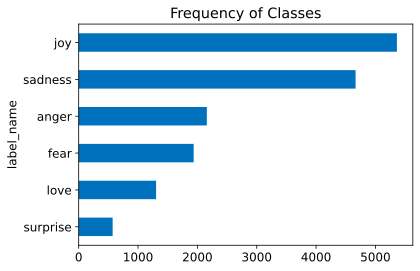

In [48]:
import matplotlib.pyplot as plt

df["label_name"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of Classes")
plt.show()

## 2-5.트윗 길이 확인

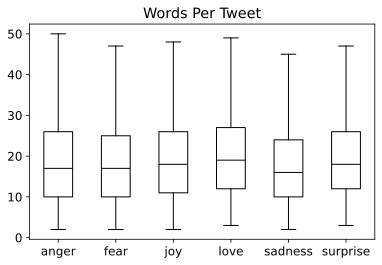

In [51]:
df["Words Per Tweet"] = df["text"].str.split().apply(len)
df.boxplot("Words Per Tweet", by="label_name", grid=False, showfliers=False,
           color="black")
plt.suptitle("")
plt.xlabel("")
plt.show()

In [52]:
emotions.reset_format()

## 2-6.텍스트에서 토큰으로

### 2-6-1.문자 토큰